The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,model_name,area_till_zero_mean
83,EGB_XGB_GAM_BEST_FIT_BEST_FIT,0.015000
82,EBM_GAM,0.427057
88,EGB_XGB_GAM_RANDOM_RANDOM,0.476904
84,EGB_XGB_GAM_CYCLIC_CYCLIC,0.492317
85,EGB_XGB_GAM_CYCLIC_RANDOM_CYCLIC_RANDOM,0.493091
86,EGB_XGB_GAM_CYCLIC_RANDOM_REVERSE_CYCLIC_RANDO...,0.493213
87,EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE,0.493631


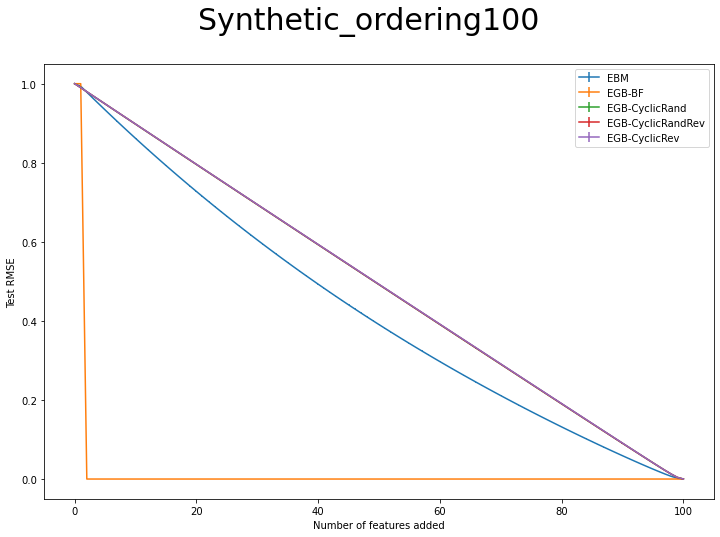

In [43]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy  as np
import ast
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False

model_name_dict = {
    #"EGB_XGB_GAM_RANDOM_RANDOM":"EGB-Rand",
        "EGB_XGB_GAM_CYCLIC_REVERSE_CYCLIC_REVERSE":"EGB-CyclicRev",
    "EGB_XGB_GAM_CYCLIC_RANDOM_CYCLIC_RANDOM":"EGB-CyclicRand",
    "EGB_XGB_GAM_CYCLIC_RANDOM_REVERSE_CYCLIC_RANDOM_REVERSE":"EGB-CyclicRandRev",
   # "EGB_XGB_GAM_CYCLIC_CYCLIC":"EGB-Cyclic",
                  "EGB_XGB_GAM_BEST_FIT_BEST_FIT":"EGB-BF",
                  "XGB":"XGBoost",
                   "EBM_GAM":"EBM",
                  "Spline":"Spline",
                  }

METHODS_LIST=model_name_dict.keys()

feature_sparsness_results = pd.read_csv("feature_sparseness_results.csv")
df = feature_sparsness_results[feature_sparsness_results["d_name"]=="synthetic_ordering100"]
display(df[["model_name","area_till_zero_mean"]].sort_values(by="area_till_zero_mean"))
df = df[df["model_name"].isin(METHODS_LIST)]

df.mean_perf = df.mean_perf.apply(ast.literal_eval)
df.std_perf = df.std_perf.apply(ast.literal_eval)

#display(df)
fig, ax = plt.subplots(figsize=(12, 8))
names_current = []
for i, results in df.iterrows():
    
    name  =  model_name_dict[results["model_name"]]
    dataset_name = results["d_name"]
    names_current += [name]
    the_mean = np.array(results["mean_perf"]).astype(float)
    the_std = results["std_perf"]
    ax.errorbar(range(len(the_mean)), the_mean, the_std, label=name)
ax.legend(names_current)
interactions = 16
fig.suptitle(dataset_name.capitalize(), fontsize=30)#  + (" - GA^2M" if interactions>0  else " - GAM"))
ax.set_xlabel('Number of features added')
ax.set_ylabel('Test RMSE')
plt.show()